# Experiment 2026-06-28 — online single-shot identification with exploratory control

Pilot experiment for the **low-data / single-continuous-trajectory** setting.

This notebook evaluates the whole online protocol, not just a final learned policy:

1. **Campaign 0:** no control, collect passive data.
2. **Campaigns 1–5:** apply exploratory control with decreasing ε.
3. **Campaigns 6–9:** pure exploitation with the learned λ-mix centrality policy.

The main question is modest on purpose:

> From one controlled run, does the nonlinear identifier learn useful predictive signal, and does the resulting online policy beat simple baselines such as no-control and uniform?

We should **not** expect the online learner to beat oracle true-v in this pilot. Oracle has the true graph from the start, while the learner spends part of the horizon exploring.


## What is tracked for every dynamics

For each dynamics model — Laplacian, COCA, and Hegselmann-Krause — the notebook reports the same diagnostics:

- **Protocol performance:** final mean/min opinion for online learned, oracle true-v, uniform, and no-control.
- **Signed gaps:** learned minus oracle, uniform, and no-control at the final campaign boundary.
- **Prediction learning:** one-step model MAE versus the identity predictor `x_next = x`.
- **Identification diagnostics:** final `A_MAE`, `A_Fro`, and centrality `v_L1` errors.
- **Rollout shape:** mean and minimum opinion trajectories over campaign boundaries.
- **Action behavior:** budget allocation over nodes and campaigns.
- **Final node distribution:** per-node final opinions for all policies.

All trajectory plots use **campaign-boundary states**. They do not show the within-campaign `t_s` samples; `t_s` only controls how many one-step training pairs are collected inside each campaign.


In [7]:
# Imports and path setup
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)


# If running from inside opinion_dynamics/experiments, make repo root importable.
def get_dir_n_levels_up(path, n):
    path = Path(path).resolve()
    for _ in range(n):
        path = path.parent
    return path


NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = get_dir_n_levels_up(NOTEBOOK_DIR, 2)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from rl_envs_forge.envs.network_graph.graph_utils import (
    compute_laplacian,
    compute_eigenvector_centrality,
)

from opinion_dynamics.utils.env_setup import EnvironmentFactory
from opinion_dynamics.experiments.rollouts import make_env_with_dynamics
from opinion_dynamics.experiments.online_single_shot import (
    run_single_shot_online_identification,
    rollout_fixed_action_policy,
    trajectory_summary_metrics,
    state_distance_metrics,
)

In [8]:
# Global config
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using DEVICE:", DEVICE)

# Pilot: one graph seed, all dynamics.
PILOT_SEED = 3
PILOT_DYNAMICS_LIST = [
    "laplacian",
    "coca",
    "hegselmannkrause",
]

# Single-shot online horizon.
NUM_CAMPAIGNS_TOTAL = 10
EXPLORATION_CAMPAIGNS = 5

# Earlier work used roughly t_campaign=2, B_campaign=1. Here we halve both.
T_CAMPAIGN = 1.0
B_CAMPAIGN = 0.5

# Lower t_s gives more one-step samples per campaign: T_CAMPAIGN / T_S transitions.
T_S = 0.1

# Learned centrality matrix:
# M_lambda(x) = (1 - lambda) A_hat + lambda (A_hat * alpha(x))
LEARNED_POLICY_LAMBDA = 0.70

# Campaign 0 is passive; campaigns 1..5 explore; campaigns 6..9 exploit.
EPSILON_SCHEDULE = [0.0, 1.0, 0.8, 0.6, 0.4, 0.2, 0.0, 0.0, 0.0, 0.0]
assert len(EPSILON_SCHEDULE) == NUM_CAMPAIGNS_TOTAL

# Identification fit settings for a small pilot.
LR = 1e-3
L2_LAMBDA = 0.0
FIT_MAX_STEPS = 2_000
FIT_MAE_STOP = 5e-3
FIT_BATCH_SIZE = 256
FIT_CHECK_EVERY = 200
IDENTIFIER_KW = {"hidden_dim": 16}

# Start from one random x0 per dynamics, generated deterministically from the seed.
RANDOM_INITIAL_OPINIONS = True
INITIAL_OPINION_LOW = 0.0
INITIAL_OPINION_HIGH = 1.0

config_summary = {
    "seed": PILOT_SEED,
    "dynamics": PILOT_DYNAMICS_LIST,
    "num_campaigns": NUM_CAMPAIGNS_TOTAL,
    "t_campaign": T_CAMPAIGN,
    "t_s": T_S,
    "B_campaign": B_CAMPAIGN,
    "lambda_mix": LEARNED_POLICY_LAMBDA,
    "epsilon_schedule": EPSILON_SCHEDULE,
}
config_summary

Using DEVICE: cpu


{'seed': 3,
 'dynamics': ['laplacian', 'coca', 'hegselmannkrause'],
 'num_campaigns': 10,
 't_campaign': 1.0,
 't_s': 0.1,
 'B_campaign': 0.5,
 'lambda_mix': 0.7,
 'epsilon_schedule': [0.0, 1.0, 0.8, 0.6, 0.4, 0.2, 0.0, 0.0, 0.0, 0.0]}

## Run pilot

The online protocol and all baselines start from the same `x0` for a given dynamics.

Baselines also use **zero control in campaign 0**, so the comparison is aligned on the first passive campaign. After that:

- `online_lambda_mix_explore_then_exploit` explores for campaigns 1–5 and exploits for campaigns 6–9.
- `oracle_true_v` uses the true graph centrality from the start of controlled campaigns.
- `uniform` spends the same per-campaign budget uniformly.
- `no_control` applies no intervention throughout.


In [9]:
# Run the single-shot pilot.
env_factory = EnvironmentFactory()
summary_rows = []
art_by_dyn = {}

for dyn_idx, DYNAMICS in enumerate(PILOT_DYNAMICS_LIST):
    print("\n" + "=" * 90)
    print(f"Running single-shot pilot: dynamics={DYNAMICS}, seed={PILOT_SEED}")
    print("=" * 90)

    env_template = make_env_with_dynamics(
        env_factory, seed=PILOT_SEED, dynamics_model=DYNAMICS
    )

    out = run_single_shot_online_identification(
        env_template,
        random_initial_opinions=RANDOM_INITIAL_OPINIONS,
        initial_opinion_low=INITIAL_OPINION_LOW,
        initial_opinion_high=INITIAL_OPINION_HIGH,
        num_campaigns_total=NUM_CAMPAIGNS_TOTAL,
        t_campaign=T_CAMPAIGN,
        t_s=T_S,
        B_campaign=B_CAMPAIGN,
        lambda_mix=LEARNED_POLICY_LAMBDA,
        exploration_campaigns=EXPLORATION_CAMPAIGNS,
        epsilon_schedule=EPSILON_SCHEDULE,
        lr=LR,
        l2_lambda=L2_LAMBDA,
        fit_max_steps=FIT_MAX_STEPS,
        fit_mae_stop=FIT_MAE_STOP,
        fit_batch_size=FIT_BATCH_SIZE,
        fit_check_every=FIT_CHECK_EVERY,
        identifier_kwargs=IDENTIFIER_KW,
        device=DEVICE,
        rng_seed=10_000 * PILOT_SEED + dyn_idx,
    )

    env_for_truth = out["env"]
    A_true = np.asarray(env_for_truth.connectivity_matrix, dtype=float)
    v_true = compute_eigenvector_centrality(compute_laplacian(A_true))

    oracle = rollout_fixed_action_policy(
        env_template,
        out["x0"],
        num_campaigns_total=NUM_CAMPAIGNS_TOTAL,
        B_campaign=B_CAMPAIGN,
        policy="oracle_true_v",
        v_true=v_true,
        zero_first_campaign=True,
        t_campaign=T_CAMPAIGN,
        t_s=T_S,
    )
    uniform = rollout_fixed_action_policy(
        env_template,
        out["x0"],
        num_campaigns_total=NUM_CAMPAIGNS_TOTAL,
        B_campaign=B_CAMPAIGN,
        policy="uniform",
        zero_first_campaign=True,
        t_campaign=T_CAMPAIGN,
        t_s=T_S,
    )
    nocontrol = rollout_fixed_action_policy(
        env_template,
        out["x0"],
        num_campaigns_total=NUM_CAMPAIGNS_TOTAL,
        B_campaign=B_CAMPAIGN,
        policy="no_control",
        zero_first_campaign=True,
        t_campaign=T_CAMPAIGN,
        t_s=T_S,
    )

    out["oracle"] = oracle
    out["uniform"] = uniform
    out["nocontrol"] = nocontrol
    out["v_true"] = v_true
    art_by_dyn[DYNAMICS] = out

    policy_states = {
        "online_lambda_mix_explore_then_exploit": out["states"],
        "oracle_true_v": oracle["states"],
        "uniform": uniform["states"],
        "no_control": nocontrol["states"],
    }
    for policy_name, states in policy_states.items():
        row = {
            "dynamics": DYNAMICS,
            "seed": PILOT_SEED,
            "policy": policy_name,
            "lambda_mix": (
                LEARNED_POLICY_LAMBDA
                if policy_name.startswith("online_lambda")
                else np.nan
            ),
            "t_campaign": T_CAMPAIGN,
            "t_s": T_S,
            "B_campaign": B_CAMPAIGN,
            "zero_first_campaign": True,
        }
        row.update(
            trajectory_summary_metrics(
                states, desired_opinion=float(env_for_truth.desired_opinion)
            )
        )
        if policy_name != "oracle_true_v":
            row.update(
                state_distance_metrics(states, oracle["states"], prefix="to_oracle_")
            )
        summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)

# Guardrail: every dynamics should have the same policies and the same number of campaign-boundary states.
expected_policies = {
    "online_lambda_mix_explore_then_exploit",
    "oracle_true_v",
    "uniform",
    "no_control",
}
for DYNAMICS in PILOT_DYNAMICS_LIST:
    observed_policies = set(
        summary_df.loc[summary_df["dynamics"] == DYNAMICS, "policy"]
    )
    assert observed_policies == expected_policies, (DYNAMICS, observed_policies)
    assert art_by_dyn[DYNAMICS]["states"].shape[0] == NUM_CAMPAIGNS_TOTAL + 1

summary_df.sort_values(["dynamics", "policy"])


Running single-shot pilot: dynamics=laplacian, seed=3
[identifier-init] class=GraphIdentifierEnvNonlinear module=opinion_dynamics.identify_nonlinear file=D:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\identify_nonlinear.py:9

Running single-shot pilot: dynamics=coca, seed=3
[identifier-init] class=GraphIdentifierEnvNonlinear module=opinion_dynamics.identify_nonlinear file=D:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\identify_nonlinear.py:9

Running single-shot pilot: dynamics=hegselmannkrause, seed=3
[identifier-init] class=GraphIdentifierEnvNonlinear module=opinion_dynamics.identify_nonlinear file=D:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\identify_nonlinear.py:9


,dynamics,seed,policy,lambda_mix,t_campaign,t_s,B_campaign,zero_first_campaign,mean_end,min_end,max_end,mean_avg,min_avg,final_mean_distance_to_desired,final_max_distance_to_desired,to_oracle_state_rmse_to_oracle_end,to_oracle_state_rmse_to_oracle_avg,to_oracle_state_linf_to_oracle_end,to_oracle_state_linf_to_oracle_max,to_oracle_mean_delta_vs_oracle_end,to_oracle_min_delta_vs_oracle_end
7,coca,3,no_control,NaN,1.0,0.1,0.5,True,0.427529,0.259196,0.519227,0.428764,0.122152,0.572471,0.740804,0.236879,0.124330,0.381405,0.383693,-0.223839,-0.265125
4,coca,3,online_lambda_mix_explore_then_exploit,0.7,1.0,0.1,0.5,True,0.580690,0.501497,0.647137,0.499278,0.255640,0.419310,0.498503,0.106658,0.082537,0.236259,0.280962,-0.070678,-0.022824
5,coca,3,oracle_true_v,NaN,1.0,0.1,0.5,True,0.651368,0.524321,0.773454,0.533297,0.218305,0.348632,0.475679,NaN,NaN,NaN,NaN,NaN,NaN
6,coca,3,uniform,NaN,1.0,0.1,0.5,True,0.595497,0.526723,0.655350,0.511227,0.281712,0.404503,0.473277,0.088897,0.067536,0.185036,0.234319,-0.055870,0.002402
11,hegselmannkrause,3,no_control,NaN,1.0,0.1,0.5,True,0.593968,0.318904,0.985738,0.594444,0.307223,0.406032,0.681096,0.297003,0.187254,0.438899,0.438899,-0.162253,-0.435244
8,hegselmannkrause,3,online_lambda_mix_explore_then_exploit,0.7,1.0,0.1,0.5,True,0.700748,0.653134,0.988591,0.646696,0.505913,0.299252,0.346866,0.121238,0.084039,0.233627,0.283115,-0.055473,-0.101014
9,hegselmannkrause,3,oracle_true_v,NaN,1.0,0.1,0.5,True,0.756221,0.754148,0.758370,0.674938,0.573553,0.243779,0.245852,NaN,NaN,NaN,NaN,NaN,NaN
10,hegselmannkrause,3,uniform,NaN,1.0,0.1,0.5,True,0.690319,0.498005,0.948663,0.639030,0.392311,0.309681,0.501995,0.175871,0.141966,0.259798,0.292839,-0.065902,-0.256143
3,laplacian,3,no_control,NaN,1.0,0.1,0.5,True,0.426669,0.424462,0.431166,0.435501,0.372437,0.573331,0.575538,0.249545,0.124366,0.288463,0.288463,-0.248064,-0.210378
0,laplacian,3,online_lambda_mix_explore_then_exploit,0.7,1.0,0.1,0.5,True,0.616060,0.580570,0.654280,0.520862,0.442469,0.383940,0.419430,0.061672,0.042326,0.100485,0.103541,-0.058673,-0.054271


## Compact protocol performance table

This is the main control-performance table.

Read the signed gaps as:

- positive `learned_minus_uniform_*`: online learned ended above uniform;
- positive `learned_minus_nocontrol_*`: online learned ended above no-control;
- negative `learned_minus_oracle_*`: online learned ended below oracle, which is expected in this online setting.


In [10]:
def _metric(summary, dynamics, policy, metric):
    match = summary[(summary["dynamics"] == dynamics) & (summary["policy"] == policy)]
    if len(match) != 1:
        raise ValueError((dynamics, policy, metric, len(match)))
    return float(match.iloc[0][metric])


compact_rows = []
for DYNAMICS in PILOT_DYNAMICS_LIST:
    learned_mean = _metric(
        summary_df, DYNAMICS, "online_lambda_mix_explore_then_exploit", "mean_end"
    )
    oracle_mean = _metric(summary_df, DYNAMICS, "oracle_true_v", "mean_end")
    uniform_mean = _metric(summary_df, DYNAMICS, "uniform", "mean_end")
    nocontrol_mean = _metric(summary_df, DYNAMICS, "no_control", "mean_end")

    learned_min = _metric(
        summary_df, DYNAMICS, "online_lambda_mix_explore_then_exploit", "min_end"
    )
    oracle_min = _metric(summary_df, DYNAMICS, "oracle_true_v", "min_end")
    uniform_min = _metric(summary_df, DYNAMICS, "uniform", "min_end")
    nocontrol_min = _metric(summary_df, DYNAMICS, "no_control", "min_end")

    compact_rows.append(
        {
            "dynamics": DYNAMICS,
            "learned_mean_end": learned_mean,
            "oracle_mean_end": oracle_mean,
            "uniform_mean_end": uniform_mean,
            "nocontrol_mean_end": nocontrol_mean,
            "learned_minus_oracle_mean_end": learned_mean - oracle_mean,
            "learned_minus_uniform_mean_end": learned_mean - uniform_mean,
            "learned_minus_nocontrol_mean_end": learned_mean - nocontrol_mean,
            "learned_min_end": learned_min,
            "oracle_min_end": oracle_min,
            "uniform_min_end": uniform_min,
            "nocontrol_min_end": nocontrol_min,
            "learned_minus_oracle_min_end": learned_min - oracle_min,
            "learned_minus_uniform_min_end": learned_min - uniform_min,
            "learned_minus_nocontrol_min_end": learned_min - nocontrol_min,
        }
    )

compact_performance_df = pd.DataFrame(compact_rows)
compact_performance_df.round(4)

,dynamics,learned_mean_end,oracle_mean_end,uniform_mean_end,nocontrol_mean_end,learned_minus_oracle_mean_end,learned_minus_uniform_mean_end,learned_minus_nocontrol_mean_end,learned_min_end,oracle_min_end,uniform_min_end,nocontrol_min_end,learned_minus_oracle_min_end,learned_minus_uniform_min_end,learned_minus_nocontrol_min_end
0,laplacian,0.6161,0.6747,0.5774,0.4267,-0.0587,0.0386,0.1894,0.5806,0.6348,0.5758,0.4245,-0.0543,0.0048,0.1561
1,coca,0.5807,0.6514,0.5955,0.4275,-0.0707,-0.0148,0.1532,0.5015,0.5243,0.5267,0.2592,-0.0228,-0.0252,0.2423
2,hegselmannkrause,0.7007,0.7562,0.6903,0.5940,-0.0555,0.0104,0.1068,0.6531,0.7541,0.4980,0.3189,-0.1010,0.1551,0.3342


## Identification and one-step prediction diagnostics

These diagnostics are about the learned model, not directly about policy performance.

The most important sanity check is:

```text
final_model_over_identity = final_train_mae / final_identity_mae
```

Values below `1.0` mean the learned one-step model predicts better than the trivial identity predictor `x_next = x` on the observed single-shot data.


In [11]:
fit_rows = []
for DYNAMICS, out in art_by_dyn.items():
    for info in out["fit_infos"]:
        row = {"dynamics": DYNAMICS}
        row.update(info)
        fit_rows.append(row)
fit_df = pd.DataFrame(fit_rows)

id_rows = []
for DYNAMICS, out in art_by_dyn.items():
    last_fit = out["fit_infos"][-1]
    id_rows.append(
        {
            "dynamics": DYNAMICS,
            "A_MAE_final": last_fit.get("A_MAE", out.get("A_MAE_final", np.nan)),
            "A_Fro_final": last_fit.get("A_Fro", out.get("A_Fro_final", np.nan)),
            "v_L1_final": last_fit.get("v_L1", out.get("v_L1_final", np.nan)),
            "final_train_mae": last_fit["train_mae"],
            "final_identity_mae": last_fit["identity_mae"],
            "final_model_over_identity": last_fit["model_over_identity"],
            "n_pairs_final": last_fit["n_pairs"],
        }
    )

id_df = pd.DataFrame(id_rows)
id_df.round(5)


,dynamics,A_MAE_final,A_Fro_final,v_L1_final,final_train_mae,final_identity_mae,final_model_over_identity,n_pairs_final
0,laplacian,NaN,NaN,NaN,0.00172,0.00378,0.45440,100
1,coca,NaN,NaN,NaN,0.00143,0.00207,0.68965,100
2,hegselmannkrause,NaN,NaN,NaN,0.00428,0.00400,1.07055,100


## Plot helpers

The following cells intentionally use the same plotting functions for all dynamics. This makes the pilot easier to compare and reduces the chance that one dynamics receives extra diagnostics while another is skipped.


In [12]:
POLICY_LABELS = {
    "online": "online: explore→exploit λ-mix",
    "oracle": "oracle true-v baseline",
    "uniform": "uniform baseline",
    "nocontrol": "no-control baseline",
}

POLICY_STYLES = {
    "online": dict(marker="o", linestyle="-", linewidth=2.5),
    "oracle": dict(marker="s", linestyle="--", linewidth=2.0),
    "uniform": dict(marker="^", linestyle="-.", linewidth=2.0),
    "nocontrol": dict(marker="x", linestyle=":", linewidth=2.0),
}


def campaign_boundary_time(n_states):
    return np.arange(n_states) * T_CAMPAIGN


def add_protocol_shading(ax):
    ax.axvspan(0, T_CAMPAIGN, alpha=0.08, label="campaign 0: no control")
    ax.axvspan(
        T_CAMPAIGN,
        (EXPLORATION_CAMPAIGNS + 1) * T_CAMPAIGN,
        alpha=0.06,
        label="campaigns 1–5: exploration",
    )


def policy_state_series(out):
    return {
        "online": out["states"],
        "oracle": out["oracle"]["states"],
        "uniform": out["uniform"]["states"],
        "nocontrol": out["nocontrol"]["states"],
    }


def plot_boundary_metric_by_policy(DYNAMICS, metric="mean"):
    out = art_by_dyn[DYNAMICS]
    fig, ax = plt.subplots(figsize=(9.5, 3.6))
    add_protocol_shading(ax)

    for key, states in policy_state_series(out).items():
        t = campaign_boundary_time(states.shape[0])
        if metric == "mean":
            y = states.mean(axis=1)
            ylabel = "mean opinion"
            metric_title = "mean opinion"
        elif metric == "min":
            y = states.min(axis=1)
            ylabel = "minimum node opinion"
            metric_title = "minimum opinion"
        else:
            raise ValueError(metric)
        ax.plot(t, y, label=POLICY_LABELS[key], **POLICY_STYLES[key])

    ax.set_xlabel("campaign-boundary time")
    ax.set_ylabel(ylabel)
    ax.set_title(
        f"Single-shot online protocol vs baselines — {metric_title} — {DYNAMICS}, seed={PILOT_SEED}\n"
        f"t_campaign={T_CAMPAIGN}, t_s={T_S}, B_campaign={B_CAMPAIGN}, λ={LEARNED_POLICY_LAMBDA}"
    )
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.30), ncol=2, frameon=False)
    fig.subplots_adjust(bottom=0.36)
    plt.show()


def plot_fit_diagnostics(DYNAMICS):
    sub = fit_df[fit_df["dynamics"] == DYNAMICS].copy()
    if sub.empty:
        return

    fig, ax = plt.subplots(figsize=(8.8, 3.2))
    ax.plot(
        sub["campaign"],
        sub["train_mae"],
        marker="o",
        label="learned model one-step MAE",
    )
    ax.plot(
        sub["campaign"], sub["identity_mae"], marker="s", label="identity baseline MAE"
    )
    ax.set_xlabel("campaign index after refit")
    ax.set_ylabel("one-step MAE on accumulated observed pairs")
    ax.set_title(f"Prediction fit from one trajectory — {DYNAMICS}, seed={PILOT_SEED}")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.28), ncol=2, frameon=False)
    fig.subplots_adjust(bottom=0.33)
    plt.show()

    fig, ax = plt.subplots(figsize=(8.8, 2.8))
    ax.plot(sub["campaign"], sub["model_over_identity"], marker="o")
    ax.axhline(1.0, linewidth=1)
    ax.set_xlabel("campaign index after refit")
    ax.set_ylabel("model MAE / identity MAE")
    ax.set_title(f"Does the learned model beat x_next = x? — {DYNAMICS}")
    ax.grid(True, alpha=0.3)
    plt.show()


def plot_action_diagnostics(DYNAMICS):
    out = art_by_dyn[DYNAMICS]
    actions = np.asarray(out["actions"], dtype=float)
    eps = np.asarray(out["epsilon_schedule"], dtype=float)

    fig, ax = plt.subplots(figsize=(9.5, 3.3))
    im = ax.imshow(actions.T, aspect="auto", interpolation="nearest")
    ax.set_xlabel("campaign index k")
    ax.set_ylabel("node index i")
    ax.set_title(
        f"Online run action allocation — {DYNAMICS}, seed={PILOT_SEED}\n"
        "campaign 0 is passive; campaigns 1–5 explore; campaigns 6–9 exploit"
    )
    ax.set_xticks(np.arange(actions.shape[0]))
    plt.colorbar(im, ax=ax, label="control u_i")
    plt.show()

    fig, ax = plt.subplots(figsize=(8.8, 2.6))
    ax.plot(np.arange(len(eps)), eps, marker="o")
    ax.set_xlabel("campaign index k")
    ax.set_ylabel("ε used for random exploration")
    ax.set_title(f"Exploration schedule used by the online policy — {DYNAMICS}")
    ax.grid(True, alpha=0.3)
    plt.show()


def plot_final_node_comparison(DYNAMICS):
    out = art_by_dyn[DYNAMICS]
    finals = {
        "online": out["states"][-1],
        "oracle": out["oracle"]["states"][-1],
        "uniform": out["uniform"]["states"][-1],
        "nocontrol": out["nocontrol"]["states"][-1],
    }

    x = np.arange(len(finals["online"]))
    fig, ax = plt.subplots(figsize=(10, 4))
    for key, row in finals.items():
        ax.plot(x, row, marker="o", label=POLICY_LABELS[key])
    ax.set_xlabel("node index i")
    ax.set_ylabel("final opinion at campaign boundary")
    ax.set_title(
        f"Final per-node opinions after the online horizon — {DYNAMICS}, seed={PILOT_SEED}"
    )
    ax.set_xticks(x)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.25), ncol=2, frameon=False)
    fig.subplots_adjust(bottom=0.30)
    plt.show()

    return pd.DataFrame(
        {
            "node": x,
            "online_explore_then_exploit": finals["online"],
            "oracle_true_v": finals["oracle"],
            "uniform": finals["uniform"],
            "no_control": finals["nocontrol"],
        }
    )

## Rollout trajectories: mean opinion

These plots show the campaign-boundary mean opinion. They answer: does the online protocol lift the average opinion relative to uniform/no-control, and how far is it from oracle?


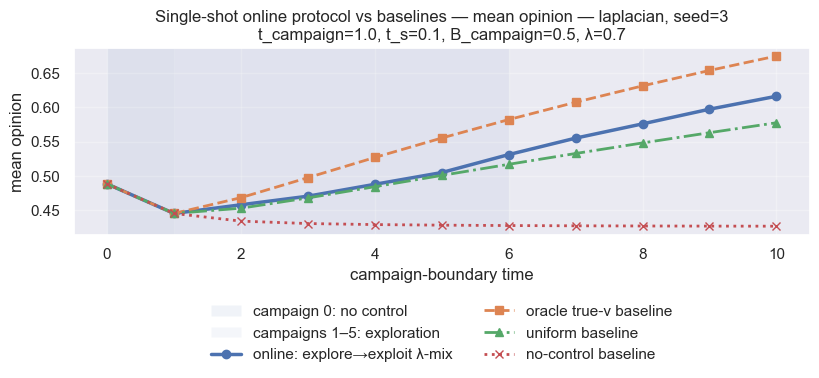

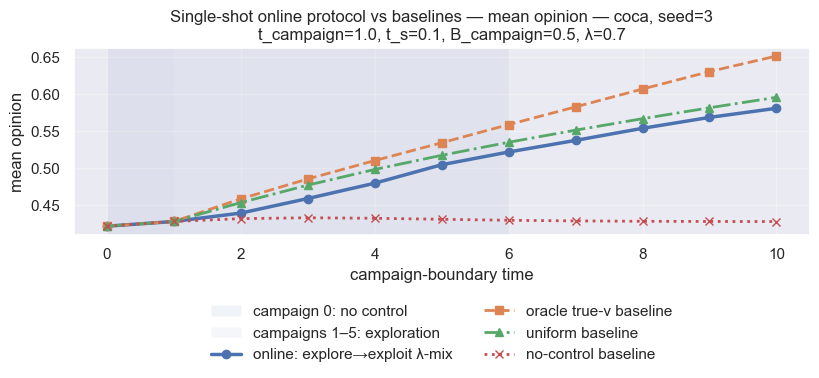

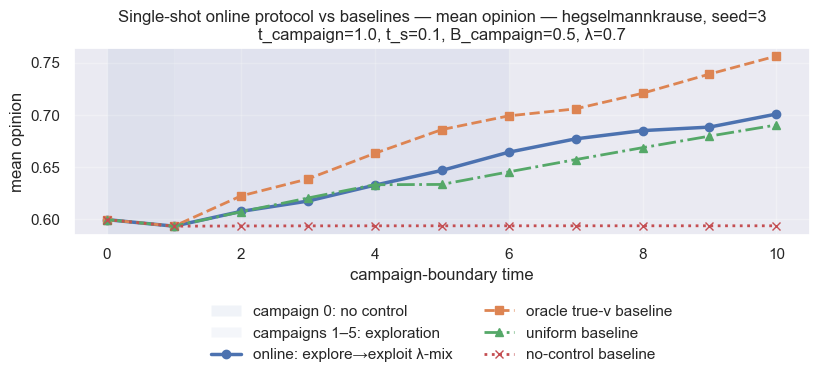

In [13]:
for DYNAMICS in PILOT_DYNAMICS_LIST:
    plot_boundary_metric_by_policy(DYNAMICS, metric="mean")

## Rollout trajectories: minimum node opinion

These plots are especially useful for nonlinear dynamics such as Hegselmann-Krause, where the average can hide isolated low-opinion nodes.


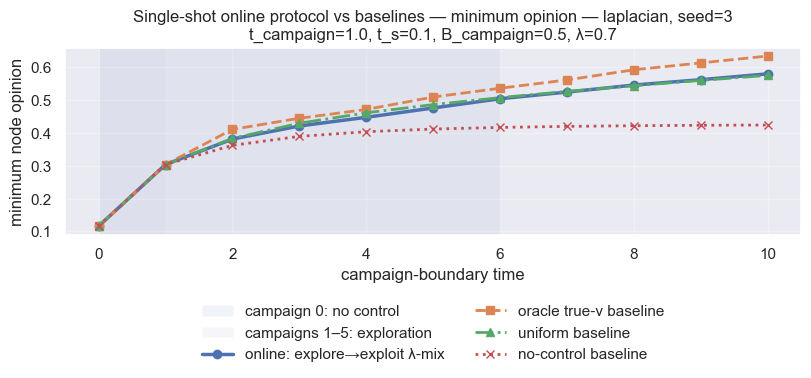

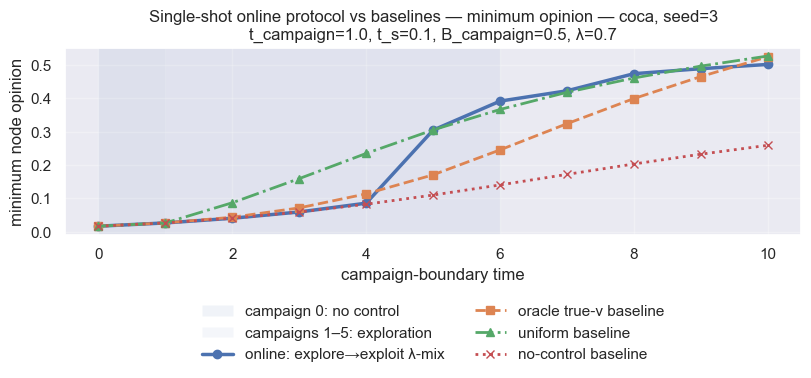

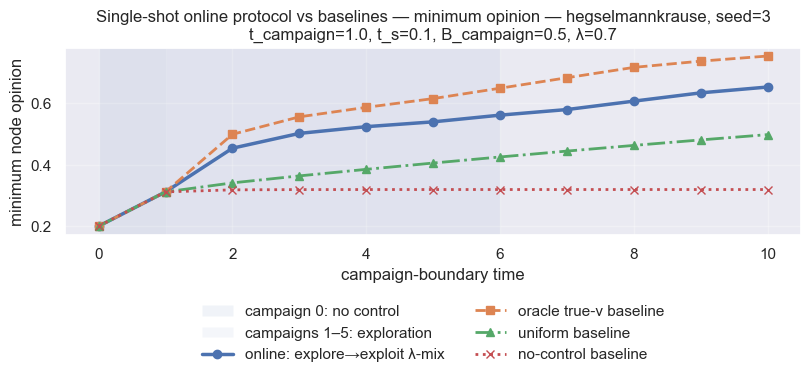

In [14]:
for DYNAMICS in PILOT_DYNAMICS_LIST:
    plot_boundary_metric_by_policy(DYNAMICS, metric="min")

## Prediction diagnostics over campaigns

These plots show whether the model improves as it accumulates samples from the single trajectory. The ratio plot is the clearest sanity check: values below `1.0` beat the identity baseline.


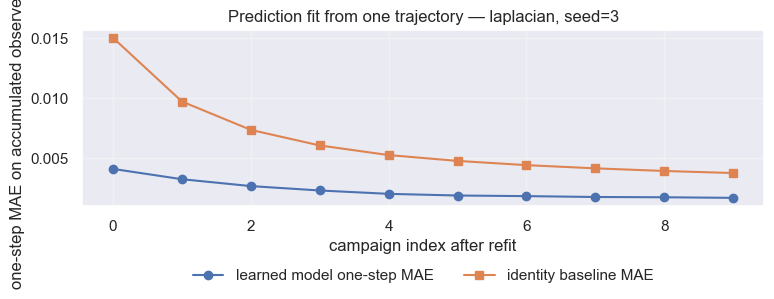

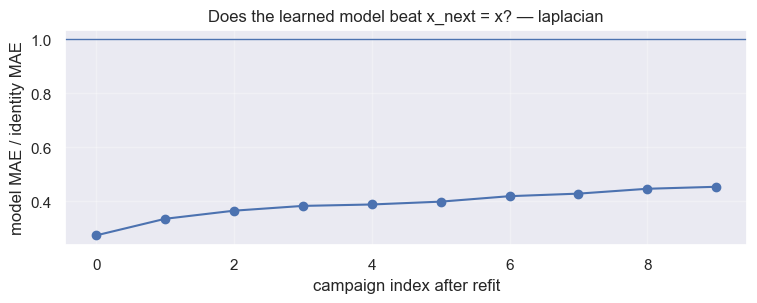

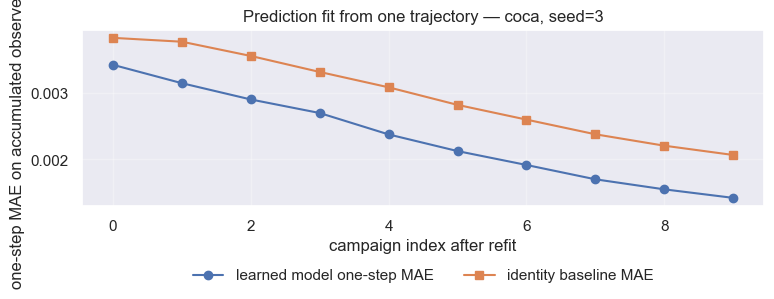

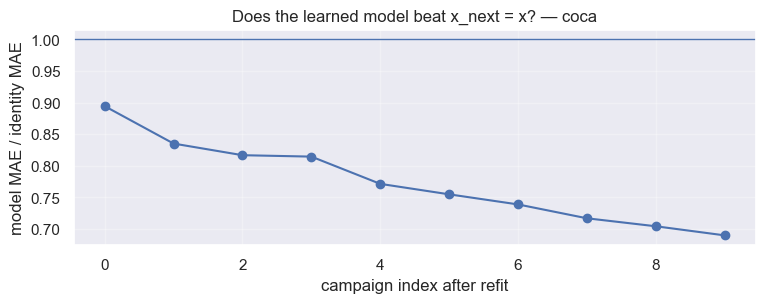

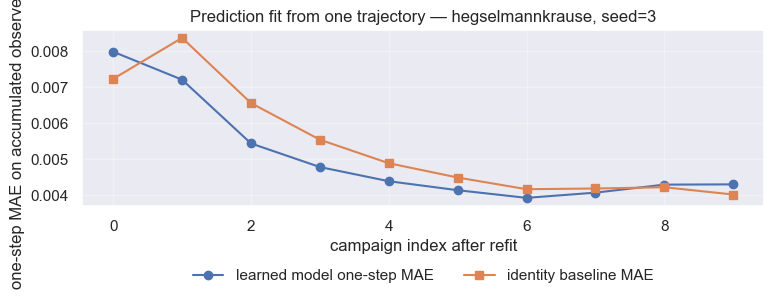

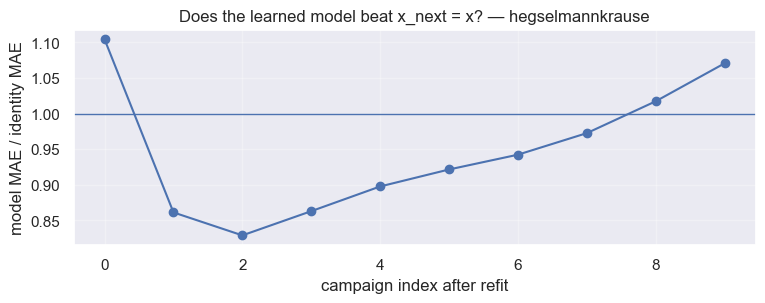

In [15]:
for DYNAMICS in PILOT_DYNAMICS_LIST:
    plot_fit_diagnostics(DYNAMICS)

## Online action diagnostics

These plots show what the online protocol actually did with the control budget. They are not baselines; they only describe the learned/exploratory run.


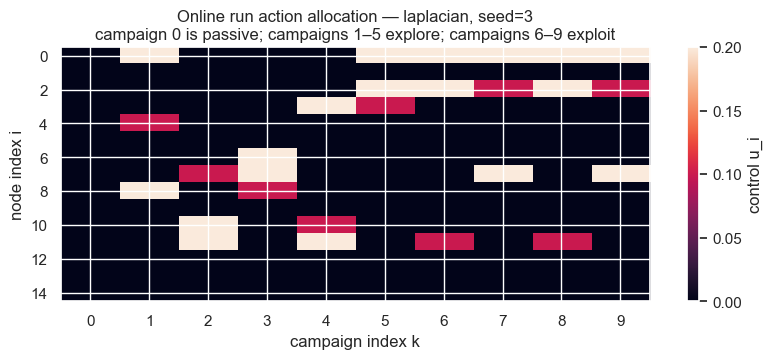

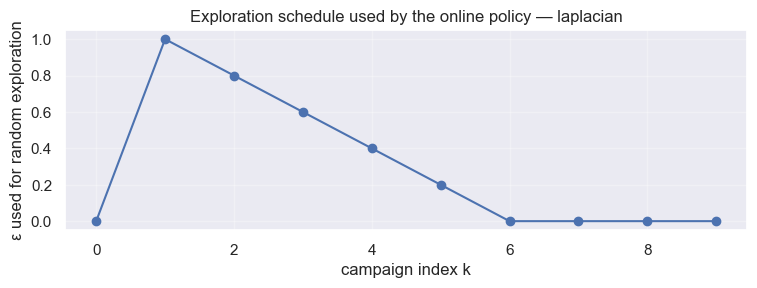

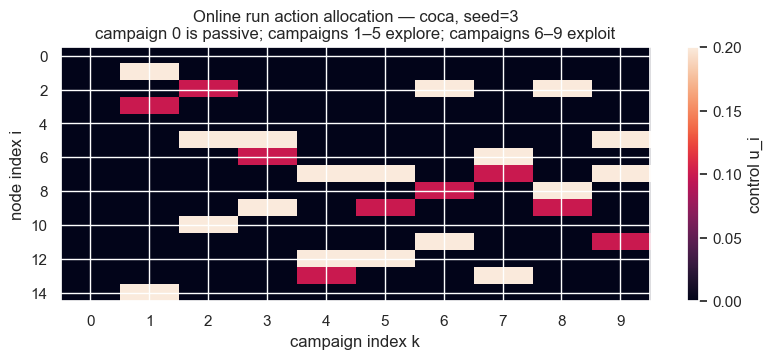

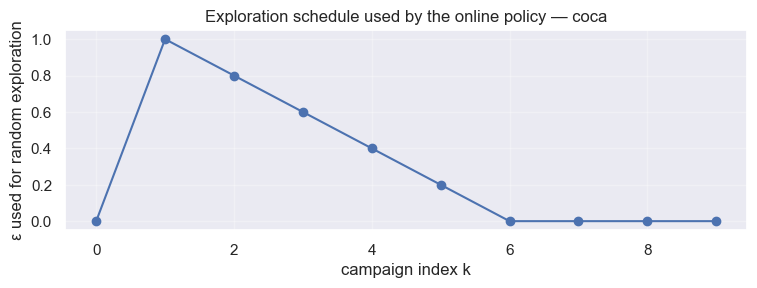

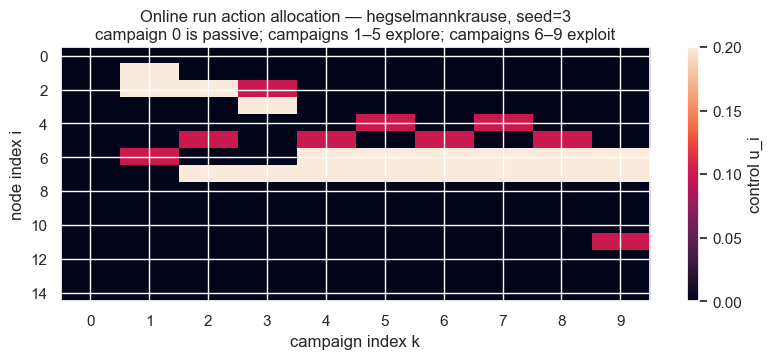

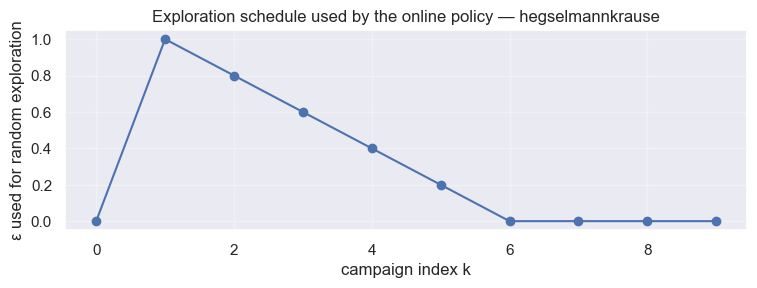

In [16]:
for DYNAMICS in PILOT_DYNAMICS_LIST:
    plot_action_diagnostics(DYNAMICS)

## Final per-node comparisons

These plots and tables reveal whether a policy lifts all nodes evenly or over-concentrates budget on already-high nodes. This is tracked for all dynamics.


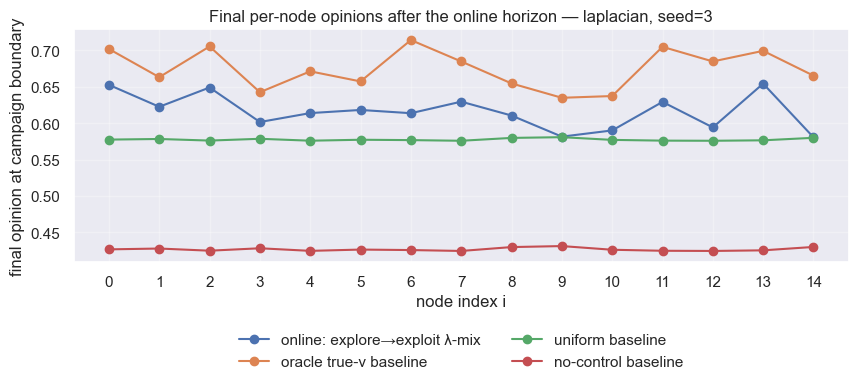

,node,online_explore_then_exploit,oracle_true_v,uniform,no_control
0,0,0.6526,0.7019,0.5774,0.4266
1,1,0.6225,0.6631,0.5783,0.4278
2,2,0.6490,0.7053,0.5761,0.4248
3,3,0.6016,0.6425,0.5785,0.4282
4,4,0.6138,0.6712,0.5759,0.4246
5,5,0.6181,0.6573,0.5772,0.4264
6,6,0.6137,0.7142,0.5767,0.4257
7,7,0.6295,0.6847,0.5758,0.4245
8,8,0.6105,0.6546,0.5797,0.4298
9,9,0.5815,0.6348,0.5807,0.4312


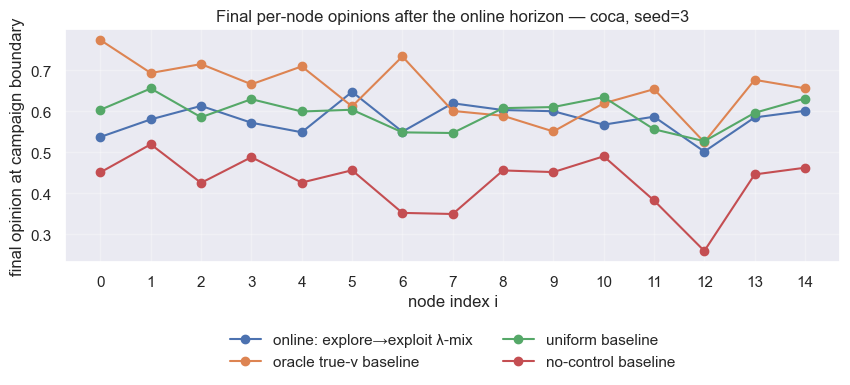

,node,online_explore_then_exploit,oracle_true_v,uniform,no_control
0,0,0.5372,0.7735,0.6034,0.4510
1,1,0.5800,0.6931,0.6554,0.5192
2,2,0.6129,0.7148,0.5852,0.4252
3,3,0.5719,0.6656,0.6293,0.4879
4,4,0.5486,0.7092,0.5992,0.4260
5,5,0.6471,0.6116,0.6035,0.4560
6,6,0.5500,0.7334,0.5484,0.3520
7,7,0.6193,0.6006,0.5468,0.3493
8,8,0.6028,0.5888,0.6074,0.4555
9,9,0.5999,0.5505,0.6101,0.4515


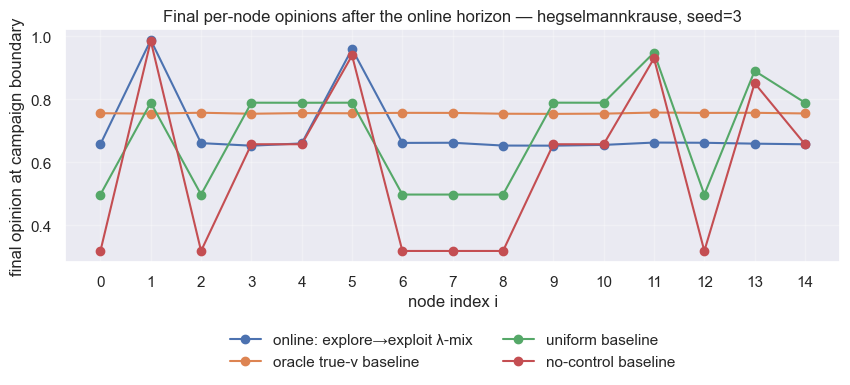

,node,online_explore_then_exploit,oracle_true_v,uniform,no_control
0,0,0.6579,0.7563,0.4980,0.3189
1,1,0.9886,0.7550,0.7897,0.9857
2,2,0.6613,0.7578,0.4980,0.3189
3,3,0.6531,0.7546,0.7896,0.6578
4,4,0.6604,0.7567,0.7895,0.6578
5,5,0.9604,0.7560,0.7897,0.9396
6,6,0.6620,0.7574,0.4980,0.3189
7,7,0.6625,0.7572,0.4980,0.3189
8,8,0.6536,0.7546,0.4980,0.3189
9,9,0.6532,0.7541,0.7897,0.6578


: 

In [ ]:
final_node_tables = {}
for DYNAMICS in PILOT_DYNAMICS_LIST:
    final_node_tables[DYNAMICS] = plot_final_node_comparison(DYNAMICS)
    display(final_node_tables[DYNAMICS].round(4))

## Interpretation checklist

Use this checklist after running the notebook:

1. **Prediction signal exists** if `final_model_over_identity < 1`.
2. **Online control is useful** if `learned_minus_nocontrol_mean_end > 0` and/or `learned_minus_nocontrol_min_end > 0`.
3. **Online control beats uniform** if the learned-minus-uniform columns are positive.
4. **Oracle gap is expected** because oracle has the true graph from the first controlled campaign and does not pay an exploration cost.
5. **Graph recovery is separate from prediction quality**: low one-step MAE does not necessarily imply low `A_MAE` or good centrality recovery from one trajectory.
